Download Data...


[*********************100%***********************]  6 of 6 completed



     RESULTS: PORTFOLIO #3 (5 STOCKS) vs. S&P 500
                         Portafolio #3 (5 Compounders) S&P 500 (SPY)
Total Return                                   324.21%        47.42%
Annualized Return (CAGR)                        81.66%        17.39%
Annualized Volatility                           27.52%        16.05%
Sharpe Ratio (Rf=4%)                              2.82          0.83
Maximum Drawdown                               -22.89%       -19.00%

Portfolio Beta #3 vs S&P 500: 1.28


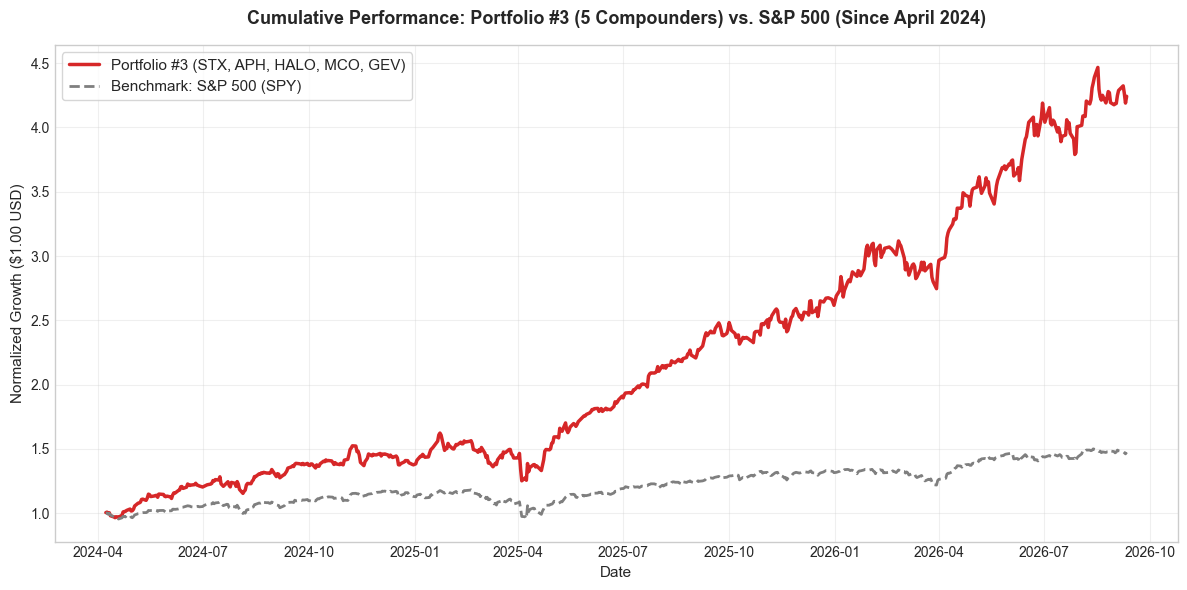

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

portfolio_tickers = ['STX', 'APH', 'HALO', 'MCO', 'GEV']
benchmark_ticker = 'SPY'

all_tickers = portfolio_tickers + [benchmark_ticker]
weights = {
    'STX':  0.20,
    'APH':  0.20,
    'HALO': 0.20,
    'MCO':  0.20,
    'GEV':  0.20
}

start_date = '2024-04-05'
print("Download Data...")
data = yf.download(all_tickers, start=start_date, auto_adjust=False)['Close']
data = data.dropna()

daily_returns = data.pct_change().dropna()

portfolio_daily_returns = pd.Series(0.0, index=daily_returns.index)

for ticker, weight in weights.items():
    portfolio_daily_returns += daily_returns[ticker] * weight

benchmark_daily_returns = daily_returns[benchmark_ticker]

portfolio_cum_returns = (1 + portfolio_daily_returns).cumprod()
benchmark_cum_returns = (1 + benchmark_daily_returns).cumprod()

def calculate_metrics(returns_series, cum_returns_series, risk_free_rate=0.04):
    total_return = cum_returns_series.iloc[-1] - 1
    num_days = len(returns_series)
    ann_return = (1 + total_return) ** (252 / num_days) - 1

    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe_ratio = (ann_return - risk_free_rate) / ann_vol

    rolling_max = cum_returns_series.cummax()
    drawdown = (cum_returns_series - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    return {
        'Total Return': f"{total_return * 100:.2f}%",
        'Annualized Return (CAGR)': f"{ann_return * 100:.2f}%",
        'Annualized Volatility': f"{ann_vol * 100:.2f}%",
        'Sharpe Ratio (Rf=4%)': f"{sharpe_ratio:.2f}",
        'Maximum Drawdown': f"{max_drawdown * 100:.2f}%"
    }

covariance = np.cov(portfolio_daily_returns, benchmark_daily_returns)[0][1]
benchmark_variance = np.var(benchmark_daily_returns)
portfolio_beta = covariance / benchmark_variance

metrics_df = pd.DataFrame({
    'Portafolio #3 (5 Compounders)': calculate_metrics(portfolio_daily_returns, portfolio_cum_returns),
    'S&P 500 (SPY)': calculate_metrics(benchmark_daily_returns, benchmark_cum_returns)
})

print("\n" + "="*55)
print("     RESULTS: PORTFOLIO #3 (5 STOCKS) vs. S&P 500")
print("="*55)
print(metrics_df)
print(f"\nPortfolio Beta #3 vs S&P 500: {portfolio_beta:.2f}")


plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.figure(figsize=(12, 6))

plt.plot(portfolio_cum_returns.index, portfolio_cum_returns,
         label='Portfolio #3 (STX, APH, HALO, MCO, GEV)',
         color='#d62728', linewidth=2.5)
plt.plot(benchmark_cum_returns.index, benchmark_cum_returns,
         label='Benchmark: S&P 500 (SPY)',
         color='#7f7f7f', linestyle='--', linewidth=2)

plt.title('Cumulative Performance: Portfolio #3 (5 Compounders) vs. S&P 500 (Since April 2024)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=11)
plt.ylabel('Normalized Growth ($1.00 USD)', fontsize=11)
plt.legend(loc='upper left', fontsize=11, frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()